In [1]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cmocean.cm as cm
import numpy as np
from pathlib import Path
import netCDF4 as nc

In [17]:
file_canada = pd.read_csv("/home/dtaneja/analysis-dishika/notebooks/RichvsMineWWTP.csv")
file_canada

,Outfall Name from Valenti-Muelas et al. (2026),Outfall Name from Rich,Population,latitude,longitude,Depth,Flow,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19
0,NaN,Capital Regional District - Clover Point,NaN,48.402500,-123.348889,67,44915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,BC Ferries,NaN,49.783333,-124.616670,3,"0,31",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Van Anda,NaN,49.758333,-124.550000,35,"17,2",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,District of Campbell River,35519.0,50.048611,-125.258333,35,20000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Powell River Regional District - Lund,NaN,49.981111,-124.761111,50,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,Lynnwood,Lynwood,38740.0,47.848000,-122.343287,30,12590.5,NaN,puget,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58,Brightwater,brightwater,110230.0,47.777687,-122.440064,182,35824.75,NaN,skagit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59,OakHarbor,Oak harbour,24760.0,48.270610,-122.647762,10,8047,NaN,skagit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,Kitsap (Central Kitsap WWTP),Kitsap,12180.0,47.677189,-122.602822,12.5,3958.5,NaN,puget,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
points = {}
for _,row in file_canada.iterrows():
    points[row["Outfall Name from Rich"]] = (row["longitude"],row["latitude"])
points

{'Capital Regional District - Clover Point': (-123.348889, 48.4025),
 'BC Ferries': (-124.61667, 49.783333),
 'Van Anda': (-124.55, 49.758333),
 'District of Campbell River': (-125.258333, 50.048611),
 'Powell River Regional District - Lund': (-124.7611111, 49.9811111),
 'Quathiaski Cove': (-125.217, 50.051),
 'Sliammon': (-124.6083333, 49.8969444),
 'Sundowner': (-124.025259, 49.62253832),
 'Cape Mudge Band': (-125.18444, 49.99972),
 'Cumberland': (-125.03613, 49.61634),
 'Gillies Bay': (-124.48333, 49.683333),
 'Wildwood': (-124.513893, 49.830452),
 'Nanoose FN': (-124.193054, 49.272316),
 'Westview': (-124.528876410001, 49.8371656881596),
 'Town of Gibsons WWTP': (-123.50912417875, 49.4005691328716),
 'Snug Cove WWTP': (-123.332078459847, 49.3796392381716),
 'Citrus Wynd WWTP': (-123.250249795345, 49.3974552422354),
 'Riverport WWTP': (-123.060988116488, 49.1363763192682),
 'TFN Sewage Treatment Plant': (-123.098053077777, 49.053303965667),
 'French Creek Pollution Control': (-124.3

In [4]:
print(len(file_canada))

62


In [5]:
print(len(points))

61


In [6]:
grid_dir = Path("/ocean/atall/MOAD/grid/")
grid_map = Path("grid_from_lat_lon_mask999.nc")
grid_lons_lats = xr.open_dataset(grid_dir / grid_map)

In [7]:
# Coordinates of points in grid indices
point_indices = {}

for name, (lon_sta, lat_sta) in points.items():

    jj = grid_lons_lats.jj.sel(
        lats=lat_sta,
        lons=lon_sta,
        method='nearest'
    ).item()

    ii = grid_lons_lats.ii.sel(
        lats=lat_sta,
        lons=lon_sta,
        method='nearest'
    ).item()

    point_indices[name] = (jj, ii)

In [8]:
point_indices

{'Capital Regional District - Clover Point': (295, 198),
 'BC Ferries': (653, 184),
 'Van Anda': (643, 191),
 'District of Campbell River': (750, 123),
 'Powell River Regional District - Lund': (702, 188),
 'Quathiaski Cove': (748, 129),
 'Sliammon': (675, 200),
 'Sundowner': (580, 251),
 'Cape Mudge Band': (735, 128),
 'Cumberland': (650, 102),
 'Gillies Bay': (624, 192),
 'Wildwood': (655, 206),
 'Nanoose FN': (523, 183),
 'Westview': (657, 204),
 'Town of Gibsons WWTP': (500, 299),
 'Snug Cove WWTP': (483, 323),
 'Citrus Wynd WWTP': (481, 337),
 'Riverport WWTP': (415, 332),
 'TFN Sewage Treatment Plant': (403, 316),
 'French Creek Pollution Control': (549, 167),
 'Nanoose Bay Pollution Control': (523, 191),
 'SnawnNaw-As WWTP': (515, 190),
 'Duke Point Pollution Control': (475, 213),
 'CFB Equimault/Rocky Point': (306, 190),
 'PA Region - William Head': (301, 164),
 'Tsawout WWTP': (335, 216),
 'Magic Lake': (361, 252),
 'Greater Vancouver Regional District': (460, 340),
 'Greater 

In [9]:
len(point_indices)

61

In [10]:
mesh = xr.open_dataset("/ocean/atall/MOAD/grid/mesh_mask202108.nc")
mesh["tmask"]

<xarray.DataArray 'tmask' (t: 1, z: 40, y: 898, x: 398)> Size: 14MB
[14296160 values with dtype=int8]
Dimensions without coordinates: t, z, y, x
Attributes:
    standard_name:  tmask
    long_name:      mask for T-grid and W-grid
    flag_values:    0, 1
    flag_meanings:  land, water

In [11]:
mesh["tmask"].shape

(1, 40, 898, 398)

In [12]:
tmask_2d = mesh["tmask"].values[0, 0, :, :]
print(tmask_2d.shape)

(898, 398)


In [13]:
tmask_2d[653, 184]

np.int8(0)

In [14]:
tmask_2d[295, 198]

np.int8(1)

In [15]:
# Puyallup
jj = grid_lons_lats.jj.sel(
        lats=47.20518904173506,
        lons=-122.32189178090265,
        method='nearest'
    ).item()

ii = grid_lons_lats.ii.sel(
        lats=47.20518904173506,
        lons=-122.32189178090265,
        method='nearest'
    ).item()

jj,ii

(-999, -999)

Puyallup is out of bounds therefore, removing this for now.

In [22]:
file_canada = file_canada[file_canada['Outfall Name from Rich'] != "Puyallup"]
file_canada

,Outfall Name from Valenti-Muelas et al. (2026),Outfall Name from Rich,Population,latitude,longitude,Depth,Flow,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19
0,NaN,Capital Regional District - Clover Point,NaN,48.402500,-123.348889,67,44915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,BC Ferries,NaN,49.783333,-124.616670,3,"0,31",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Van Anda,NaN,49.758333,-124.550000,35,"17,2",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,District of Campbell River,35519.0,50.048611,-125.258333,35,20000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Powell River Regional District - Lund,NaN,49.981111,-124.761111,50,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,Lynnwood,Lynwood,38740.0,47.848000,-122.343287,30,12590.5,NaN,puget,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58,Brightwater,brightwater,110230.0,47.777687,-122.440064,182,35824.75,NaN,skagit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59,OakHarbor,Oak harbour,24760.0,48.270610,-122.647762,10,8047,NaN,skagit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,Kitsap (Central Kitsap WWTP),Kitsap,12180.0,47.677189,-122.602822,12.5,3958.5,NaN,puget,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
points = {}
for _,row in file_canada.iterrows():
    points[row["Outfall Name from Rich"]] = (row["longitude"],row["latitude"])
points

{'Capital Regional District - Clover Point': (-123.348889, 48.4025),
 'BC Ferries': (-124.61667, 49.783333),
 'Van Anda': (-124.55, 49.758333),
 'District of Campbell River': (-125.258333, 50.048611),
 'Powell River Regional District - Lund': (-124.7611111, 49.9811111),
 'Quathiaski Cove': (-125.217, 50.051),
 'Sliammon': (-124.6083333, 49.8969444),
 'Sundowner': (-124.025259, 49.62253832),
 'Cape Mudge Band': (-125.18444, 49.99972),
 'Cumberland': (-125.03613, 49.61634),
 'Gillies Bay': (-124.48333, 49.683333),
 'Wildwood': (-124.513893, 49.830452),
 'Nanoose FN': (-124.193054, 49.272316),
 'Westview': (-124.528876410001, 49.8371656881596),
 'Town of Gibsons WWTP': (-123.50912417875, 49.4005691328716),
 'Snug Cove WWTP': (-123.332078459847, 49.3796392381716),
 'Citrus Wynd WWTP': (-123.250249795345, 49.3974552422354),
 'Riverport WWTP': (-123.060988116488, 49.1363763192682),
 'TFN Sewage Treatment Plant': (-123.098053077777, 49.053303965667),
 'French Creek Pollution Control': (-124.3

In [24]:
# Coordinates of points in grid indices
point_indices = {}

for name, (lon_sta, lat_sta) in points.items():

    jj = grid_lons_lats.jj.sel(
        lats=lat_sta,
        lons=lon_sta,
        method='nearest'
    ).item()

    ii = grid_lons_lats.ii.sel(
        lats=lat_sta,
        lons=lon_sta,
        method='nearest'
    ).item()

    point_indices[name] = (jj, ii)

In [25]:
point_indices

{'Capital Regional District - Clover Point': (295, 198),
 'BC Ferries': (653, 184),
 'Van Anda': (643, 191),
 'District of Campbell River': (750, 123),
 'Powell River Regional District - Lund': (702, 188),
 'Quathiaski Cove': (748, 129),
 'Sliammon': (675, 200),
 'Sundowner': (580, 251),
 'Cape Mudge Band': (735, 128),
 'Cumberland': (650, 102),
 'Gillies Bay': (624, 192),
 'Wildwood': (655, 206),
 'Nanoose FN': (523, 183),
 'Westview': (657, 204),
 'Town of Gibsons WWTP': (500, 299),
 'Snug Cove WWTP': (483, 323),
 'Citrus Wynd WWTP': (481, 337),
 'Riverport WWTP': (415, 332),
 'TFN Sewage Treatment Plant': (403, 316),
 'French Creek Pollution Control': (549, 167),
 'Nanoose Bay Pollution Control': (523, 191),
 'SnawnNaw-As WWTP': (515, 190),
 'Duke Point Pollution Control': (475, 213),
 'CFB Equimault/Rocky Point': (306, 190),
 'PA Region - William Head': (301, 164),
 'Tsawout WWTP': (335, 216),
 'Magic Lake': (361, 252),
 'Greater Vancouver Regional District': (460, 340),
 'Greater 

In [26]:
canada_status = file_canada[["Outfall Name from Rich", "latitude", "longitude","Depth"]].copy()
canada_status["status"] = "unknown"
for key,value in point_indices.items():
    if int(tmask_2d[value[0],value[1]]) == 1:
        status = "water"
    elif int(tmask_2d[value[0],value[1]]) == 0:
        status = "land"
    else:
        status = "unknown"

    canada_status.loc[canada_status["Outfall Name from Rich"] == key,"status"] = status

In [27]:
canada_status

,Outfall Name from Rich,latitude,longitude,Depth,status
0,Capital Regional District - Clover Point,48.402500,-123.348889,67,water
1,BC Ferries,49.783333,-124.616670,3,land
2,Van Anda,49.758333,-124.550000,35,land
3,District of Campbell River,50.048611,-125.258333,35,water
4,Powell River Regional District - Lund,49.981111,-124.761111,50,land
...,...,...,...,...,...
57,Lynwood,47.848000,-122.343287,30,land
58,brightwater,47.777687,-122.440064,182,water
59,Oak harbour,48.270610,-122.647762,10,water
60,Kitsap,47.677189,-122.602822,12.5,water


In [28]:
(canada_status["status"]=="water").sum()

np.int64(38)

/tmp/ipykernel_726021/1806203035.py:7: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
/home/dtaneja/analysis-dishika/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


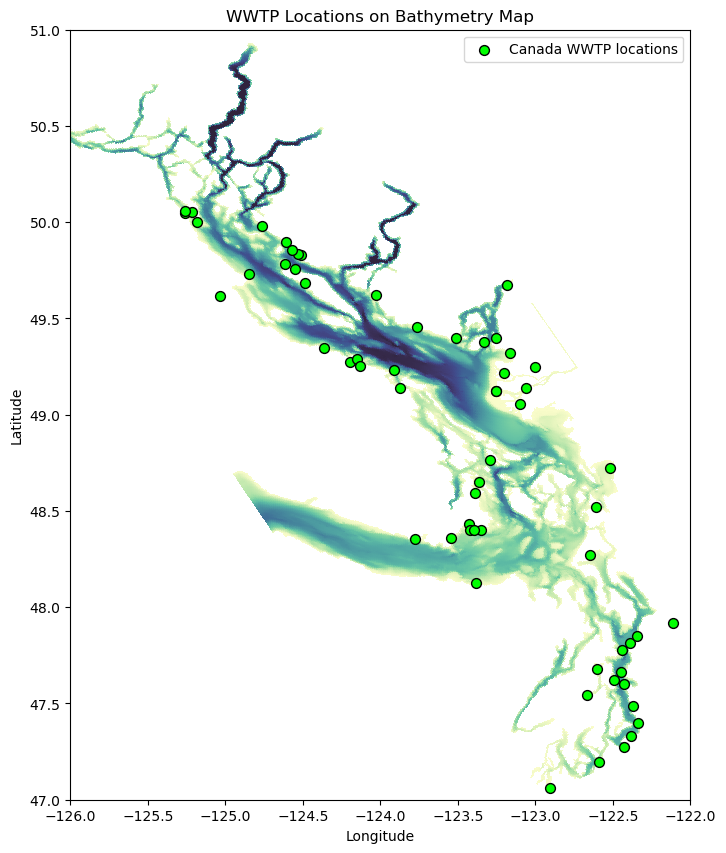

In [29]:
bathy = xr.open_dataset("/ocean/atall/MOAD/grid/bathymetry_202108.nc")
bathy_data = bathy["Bathymetry"]
lon_grid = bathy["nav_lon"]
lat_grid = bathy["nav_lat"]

fig, ax = plt.subplots(figsize=(8, 10))
mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
ax.scatter(canada_status["longitude"],canada_status["latitude"],color="lime",edgecolor="black",s=50,label="Canada WWTP locations")
ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.set_title("WWTP Locations on Bathymetry Map")
ax.legend()
plt.show()

In [30]:
def haversine_km(lon1, lat1, lon2, lat2):
    R = 6371  
    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)
    dlon = lon1 - lon2
    dlat = lat1 - lat2
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

In [31]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [ ]:
type(tmask_2d)

numpy.ndarray

In [33]:
type(lon_grid)

xarray.core.dataarray.DataArray

In [35]:
#Extract the longitude, latitude, and depth of grid cells which are in water in the bathymetry map
lon_vals = lon_grid.values
lat_vals = lat_grid.values
depth_vals = bathy_data.values

water_j, water_i = np.where(tmask_2d == 1)
water_lons = lon_vals[water_j, water_i]
water_lats = lat_vals[water_j, water_i]
water_depths = depth_vals[water_j, water_i]

canada_status["nearest_water_j"] = np.nan
canada_status["nearest_water_i"] = np.nan
canada_status["nearest_water_lon"] = np.nan
canada_status["nearest_water_lat"] = np.nan
canada_status["nearest_water_depth"] = np.nan

In [36]:
# Finds the nearest water grid cell for each Canada WWTP point that is currently marked as "land"
for name, (jj, ii) in point_indices.items():
    row_mask = canada_status["Outfall Name from Rich"] == name
    status = canada_status.loc[row_mask, "status"].iloc[0]
    if status == "water":
        continue
    point_lon = canada_status.loc[row_mask, "longitude"].iloc[0]
    point_lat = canada_status.loc[row_mask, "latitude"].iloc[0]
    distances = haversine_km(water_lons,water_lats,point_lon,point_lat)
    k = np.argmin(distances)
    nearest_j = water_j[k]
    nearest_i = water_i[k]
    canada_status.loc[row_mask, "nearest_water_j"] = nearest_j
    canada_status.loc[row_mask, "nearest_water_i"] = nearest_i
    canada_status.loc[row_mask, "nearest_water_lon"] = lon_vals[nearest_j, nearest_i]
    canada_status.loc[row_mask, "nearest_water_lat"] = lat_vals[nearest_j, nearest_i]
    canada_status.loc[row_mask, "nearest_water_depth"] = depth_vals[nearest_j, nearest_i]
   

In [37]:
canada_status

,Outfall Name from Rich,latitude,longitude,Depth,status,nearest_water_j,nearest_water_i,nearest_water_lon,nearest_water_lat,nearest_water_depth
0,Capital Regional District - Clover Point,48.402500,-123.348889,67,water,NaN,NaN,NaN,NaN,NaN
1,BC Ferries,49.783333,-124.616670,3,land,652.0,182.0,-124.626236,49.775177,22.0000
2,Van Anda,49.758333,-124.550000,35,land,644.0,191.0,-124.553001,49.760780,75.0625
3,District of Campbell River,50.048611,-125.258333,35,water,NaN,NaN,NaN,NaN,NaN
4,Powell River Regional District - Lund,49.981111,-124.761111,50,land,702.0,187.0,-124.766167,49.979462,54.1875
5,Quathiaski Cove,50.051000,-125.217000,24,land,748.0,128.0,-125.224663,50.048996,28.3750
6,Sliammon,49.896944,-124.608333,15,land,674.0,200.0,-124.606064,49.894527,9.7500
7,Sundowner,49.622538,-124.025259,21,land,580.0,252.0,-124.023827,49.625122,5.8125
8,Cape Mudge Band,49.999720,-125.184440,14,land,735.0,127.0,-125.186966,49.996349,19.0625
9,Cumberland,49.616340,-125.036130,0,land,652.0,119.0,-124.953186,49.656891,4.0000


In [38]:
canada_status["Depth"].dtype

<StringDtype(na_value=nan)>

In [39]:
canada_status["nearest_water_depth"].dtype

dtype('float64')

In [40]:
canada_status["Depth"] = pd.to_numeric(canada_status["Depth"], errors= "coerce")

In [41]:
canada_status["Depth"].dtype

dtype('float64')

In [42]:
count = 0
for _,row in canada_status.iterrows():
    if row["Depth"] > row["nearest_water_depth"]:
        count+=1
        print(row)
print(count)

Outfall Name from Rich      Sliammon
latitude                   49.896944
longitude                -124.608333
Depth                           15.0
status                          land
nearest_water_j                674.0
nearest_water_i                200.0
nearest_water_lon        -124.606064
nearest_water_lat          49.894527
nearest_water_depth             9.75
Name: 6, dtype: object
Outfall Name from Rich     Sundowner
latitude                   49.622538
longitude                -124.025259
Depth                           21.0
status                          land
nearest_water_j                580.0
nearest_water_i                252.0
nearest_water_lon        -124.023827
nearest_water_lat          49.625122
nearest_water_depth           5.8125
Name: 7, dtype: object
Outfall Name from Rich    Nanoose FN
latitude                   49.272316
longitude                -124.193054
Depth                           50.0
status                          land
nearest_water_j              

These 9 rows have actual depth greater than the nearest maximum depth.

In [43]:
rows_to_fix = canada_status["Depth"] > canada_status["nearest_water_depth"]
print(rows_to_fix.sum())

9


In [44]:
canada_status["corrected_water_lon"] = np.nan
canada_status["corrected_water_lat"] = np.nan
canada_status["corrected_water_depth"] = np.nan

In [45]:
search_radius_km = 5   # you can change this to 10 if needed

for idx, row in canada_status[rows_to_fix].iterrows():

    point_lon = row["longitude"]
    point_lat = row["latitude"]
    target_depth = row["Depth"]
    distances = haversine_km(water_lons,water_lats,point_lon,point_lat)
    nearby_mask = distances <= search_radius_km

    if not nearby_mask.any():
        print("No nearby water cell found for:", row["Outfall Name from Rich"])
        continue

    candidate_indices = np.where(nearby_mask)[0]

    candidate_depths = water_depths[candidate_indices]
    candidate_distances = distances[candidate_indices]

    depth_diffs = np.abs(candidate_depths - target_depth)
    best_local_idx = np.argmin(depth_diffs)
    best_k = candidate_indices[best_local_idx]

    best_j = water_j[best_k]
    best_i = water_i[best_k]

    canada_status.loc[idx, "corrected_water_lon"] = lon_vals[best_j, best_i]
    canada_status.loc[idx, "corrected_water_lat"] = lat_vals[best_j, best_i]
    canada_status.loc[idx, "corrected_water_depth"] = depth_vals[best_j, best_i]

In [46]:
canada_status

,Outfall Name from Rich,latitude,longitude,Depth,status,nearest_water_j,nearest_water_i,nearest_water_lon,nearest_water_lat,nearest_water_depth,corrected_water_lon,corrected_water_lat,corrected_water_depth
0,Capital Regional District - Clover Point,48.402500,-123.348889,67.00,water,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BC Ferries,49.783333,-124.616670,3.00,land,652.0,182.0,-124.626236,49.775177,22.0000,NaN,NaN,NaN
2,Van Anda,49.758333,-124.550000,35.00,land,644.0,191.0,-124.553001,49.760780,75.0625,NaN,NaN,NaN
3,District of Campbell River,50.048611,-125.258333,35.00,water,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Powell River Regional District - Lund,49.981111,-124.761111,50.00,land,702.0,187.0,-124.766167,49.979462,54.1875,NaN,NaN,NaN
5,Quathiaski Cove,50.051000,-125.217000,24.00,land,748.0,128.0,-125.224663,50.048996,28.3750,NaN,NaN,NaN
6,Sliammon,49.896944,-124.608333,15.00,land,674.0,200.0,-124.606064,49.894527,9.7500,-124.594246,49.888596,13.3125
7,Sundowner,49.622538,-124.025259,21.00,land,580.0,252.0,-124.023827,49.625122,5.8125,-124.054550,49.629345,20.9375
8,Cape Mudge Band,49.999720,-125.184440,14.00,land,735.0,127.0,-125.186966,49.996349,19.0625,NaN,NaN,NaN
9,Cumberland,49.616340,-125.036130,0.00,land,652.0,119.0,-124.953186,49.656891,4.0000,NaN,NaN,NaN


In [47]:
canada_status[["Depth","nearest_water_depth","corrected_water_depth"]]

,Depth,nearest_water_depth,corrected_water_depth
0,67.00,NaN,NaN
1,3.00,22.0000,NaN
2,35.00,75.0625,NaN
3,35.00,NaN,NaN
4,50.00,54.1875,NaN
5,24.00,28.3750,NaN
6,15.00,9.7500,13.3125
7,21.00,5.8125,20.9375
8,14.00,19.0625,NaN
9,0.00,4.0000,NaN


/tmp/ipykernel_726021/1895483027.py:2: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
/home/dtaneja/analysis-dishika/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


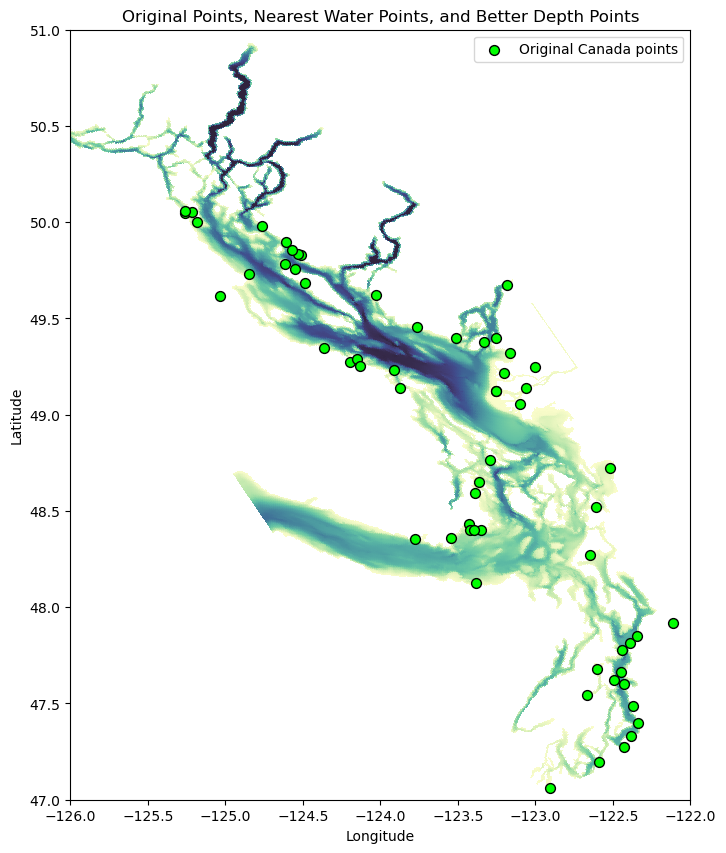

In [48]:
fig, ax = plt.subplots(figsize=(8, 10))
mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
ax.scatter(canada_status["longitude"],canada_status["latitude"],color="lime",edgecolor="black",s=50,label="Original Canada points")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(-126, -122)
ax.set_ylim(47, 51)
ax.set_title("Original Points, Nearest Water Points, and Better Depth Points")
ax.legend()
plt.show()

/tmp/ipykernel_726021/533501958.py:6: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
/home/dtaneja/analysis-dishika/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


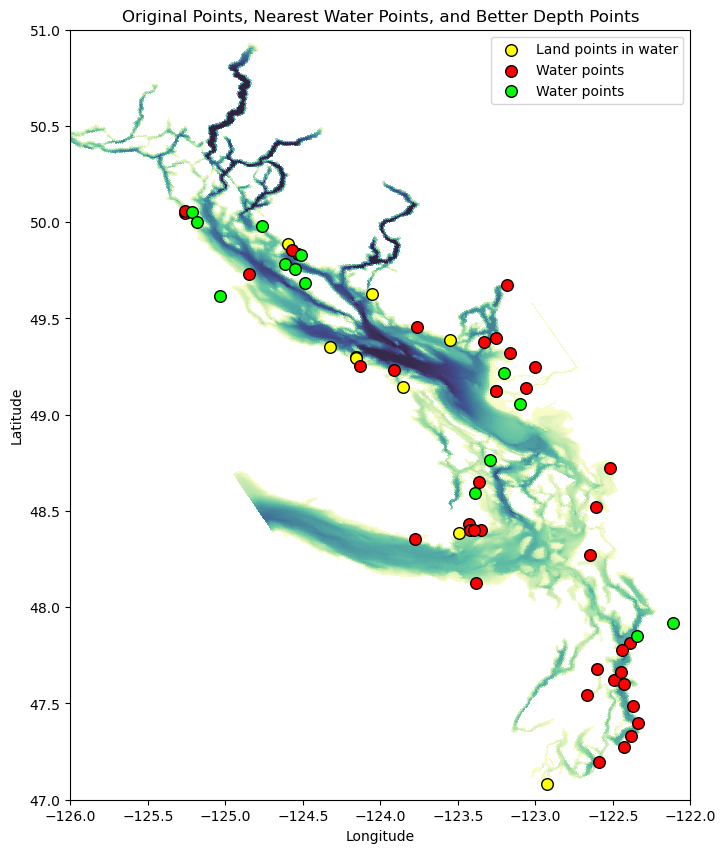

In [52]:
water_points = canada_status[canada_status["status"] == "water"].copy()
corrected_land_points = canada_status[rows_to_fix].copy()
land_points = canada_status[(canada_status["status"] == "land") & (~rows_to_fix)].copy()

fig, ax = plt.subplots(figsize=(8, 10))
mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

ax.scatter(corrected_land_points["corrected_water_lon"],corrected_land_points["corrected_water_lat"],color="yellow",edgecolor="black",s=70,label="Land points in water")
ax.scatter(water_points["longitude"],water_points["latitude"],color="red",edgecolor="black",s=70,label="Water points")
ax.scatter(land_points["longitude"],land_points["latitude"],color="lime",edgecolor="black",s=70,label="Water points")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(-126, -122)
ax.set_ylim(47, 51)
ax.set_title("Original Points, Nearest Water Points, and Better Depth Points")
ax.legend()
plt.show()

These all are corrected points from the Canadian side and all these are in water. 

/tmp/ipykernel_726021/399653172.py:6: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")


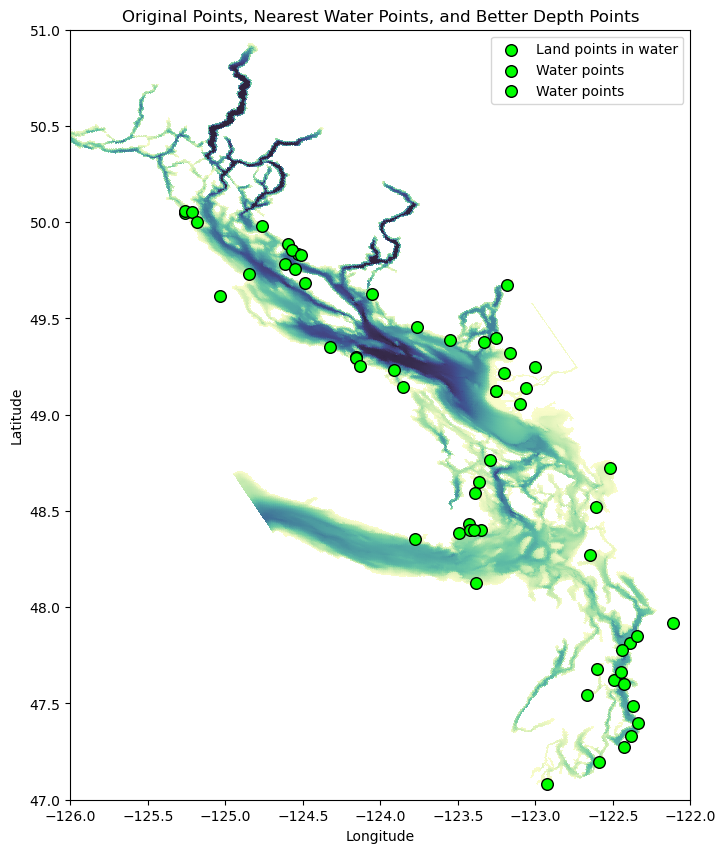

In [ ]:
water_points = canada_status[canada_status["status"] == "water"].copy()
corrected_land_points = canada_status[rows_to_fix].copy()
land_points = canada_status[(canada_status["status"] == "land") & (~rows_to_fix)].copy()

fig, ax = plt.subplots(figsize=(8, 10))
mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

ax.scatter(corrected_land_points["corrected_water_lon"],corrected_land_points["corrected_water_lat"],color="lime",edgecolor="black",s=70,label="Land points in water")
ax.scatter(water_points["longitude"],water_points["latitude"],color="lime",edgecolor="black",s=70,label="Water points")
ax.scatter(land_points["longitude"],land_points["latitude"],color="lime",edgecolor="black",s=70,label="Land points")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(-126, -122)
ax.set_ylim(47, 51)
ax.set_title("Original Points, Nearest Water Points, and Better Depth Points")
ax.legend()
plt.show()

In [59]:
file_usa = xr.open_dataset("/ocean/atall/MOAD/Obs/PugetSound/WWTP/all_point_source_data_donpon_xygrid_clim.nc")
wwtp_locs = file_usa[["nav_lon", "nav_lat"]].to_dataframe().reset_index()
wwtp_locs = wwtp_locs.dropna(subset=["nav_lon", "nav_lat"])
file_iona = xr.open_dataset("/ocean/atall/MOAD/Obs/PugetSound/WWTP/wastewater_20231010_iona.nc")
flux_max = file_usa["flux"].max(dim="time_counter")
flux_nonzero = flux_max > 0
all_y, all_x = np.where(flux_nonzero.values)
lon = file_usa["nav_lon"].isel(time_counter=0).values
lat = file_usa["nav_lat"].isel(time_counter=0).values
wwtp_locs = pd.DataFrame({"y": all_y,"x": all_x,"lon": lon[all_y, all_x],"lat": lat[all_y, all_x],"max_flux": flux_max.values[all_y, all_x]})


In [60]:
iona_flux_max = file_iona["flux"].max(dim="time_counter").fillna(0)
iona_y, iona_x = np.where(iona_flux_max.values > 0)

print(f"Found {len(iona_y)} Iona source grid cell(s)")

iona_lon_grid = file_iona["nav_lon"].values
iona_lat_grid = file_iona["nav_lat"].values

iona_lon = iona_lon_grid[iona_y, iona_x]
iona_lat = iona_lat_grid[iona_y, iona_x]

print("Iona longitude:", iona_lon)
print("Iona latitude:", iona_lat)

Found 4 Iona source grid cell(s)
Iona longitude: [-123.30531  -123.30012  -123.30867  -123.303474]
Iona latitude: [49.198967 49.20085  49.202885 49.20477 ]


/tmp/ipykernel_726021/3412260971.py:3: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
/home/dtaneja/analysis-dishika/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


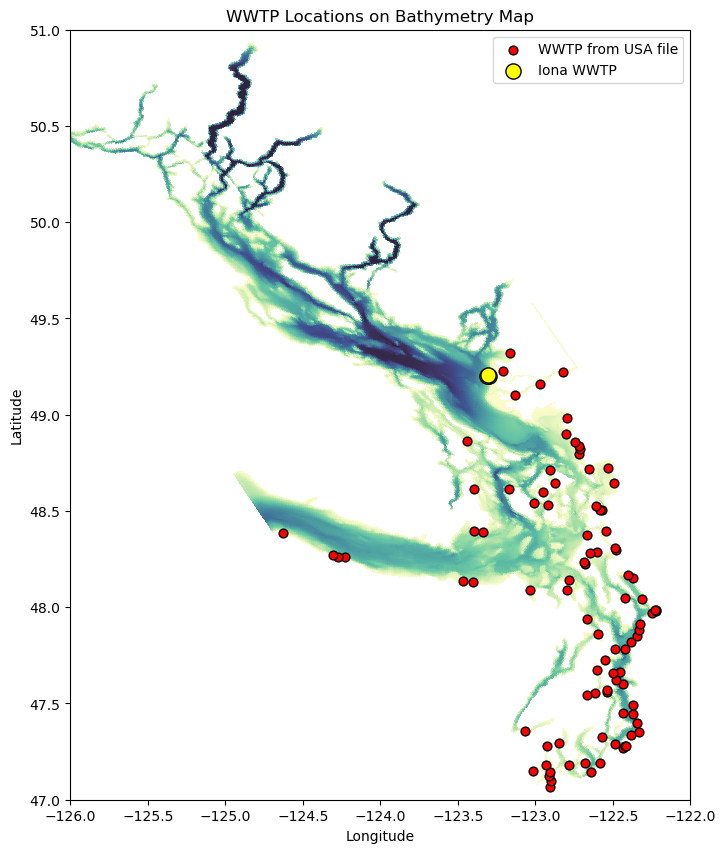

In [61]:
fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

ax.scatter(wwtp_locs["lon"],wwtp_locs["lat"],color="red",edgecolors="black",s=40,label="WWTP from USA file")
ax.scatter(iona_lon,iona_lat,color="yellow",edgecolor="black",s=120,label="Iona WWTP")

ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.set_title("WWTP Locations on Bathymetry Map")
ax.legend()
plt.show()

/tmp/ipykernel_726021/1441592190.py:3: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")


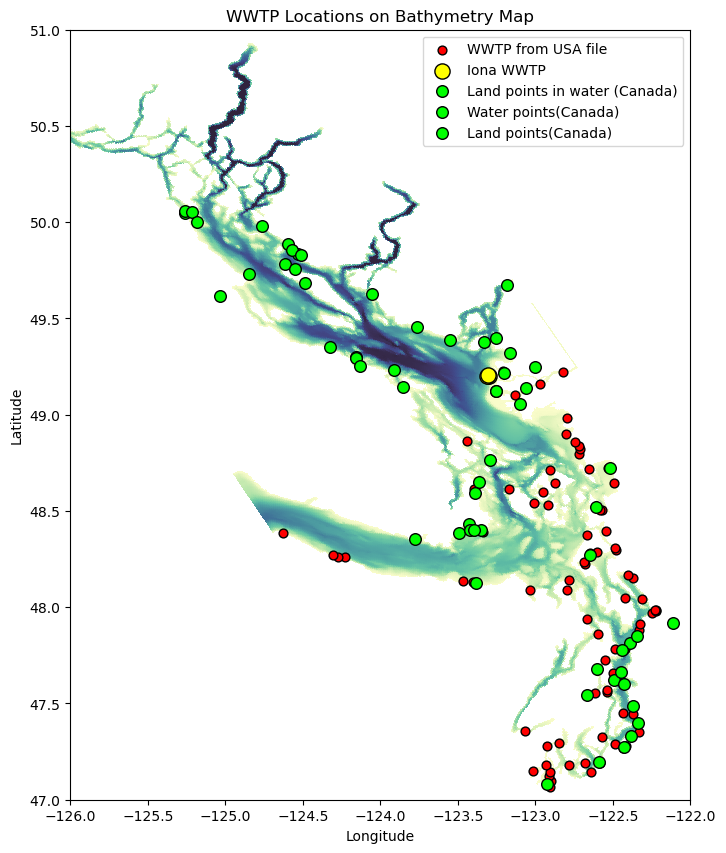

In [62]:
fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

ax.scatter(wwtp_locs["lon"],wwtp_locs["lat"],color="red",edgecolors="black",s=40,label="WWTP from USA file")
ax.scatter(iona_lon,iona_lat,color="yellow",edgecolor="black",s=120,label="Iona WWTP")
ax.scatter(corrected_land_points["corrected_water_lon"],corrected_land_points["corrected_water_lat"],color="lime",edgecolor="black",s=70,label="Land points in water (Canada)")
ax.scatter(water_points["longitude"],water_points["latitude"],color="lime",edgecolor="black",s=70,label="Water points(Canada)")
ax.scatter(land_points["longitude"],land_points["latitude"],color="lime",edgecolor="black",s=70,label="Land points(Canada)")

ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.set_title("WWTP Locations on Bathymetry Map")
ax.legend()
plt.show()